In [ ]:
## Make figure showing PFT composition (early: total basal area ratio) by patch age

In [2]:
import numpy as np
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
import pandas as pd


ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/j/jkowalcz/.conda/envs/myenv/share/proj failed


In [3]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 14
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300


In [4]:
tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'

path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'

file=tag+'.elm.h0.cat.nc'
d0=xr.open_dataset(path+file)


In [5]:
min_lat_plotting = -22.
max_lat_plotting = 12.
min_lon_plotting = 360.-82.
max_lon_plotting = 360.-42.

geog_range_plotting = [min_lon_plotting, max_lon_plotting, min_lat_plotting, max_lat_plotting]

In [6]:
Amazon_shapefile='/global/homes/j/jkowalcz/shapefileamazonecoregionwwf/amazon_ecolola.shp'

In [7]:
import shapefile
from shapely.geometry import shape, Point, LinearRing

r = shapefile.Reader(Amazon_shapefile)
shapes = r.shapes()
polygon = shape(shapes[0])

## will need to change range() argument depending on resolution

## shapefile must contain center point of grid cell
Mask = [[1 if polygon.contains(Point(d0.lon[j]-360.,d0.lat[i]))==True else 0 for i in range(23)] for j in range(24)]

Mask = np.array(Mask, dtype='int16')

In [8]:
d0.FATES_BA_APPF

<xarray.DataArray 'FATES_BA_APPF' (time: 300, fates_levagepft: 14, lat: 23,
                                   lon: 24)>
[2318400 values with dtype=float32]
Coordinates:
  * time     (time) object 0001-02-01 00:00:00 ... 0026-01-01 00:00:00
  * lon      (lon) float32 275.0 277.5 280.0 282.5 ... 325.0 327.5 330.0 332.5
  * lat      (lat) float32 -25.58 -23.68 -21.79 -19.89 ... 12.32 14.21 16.11
Dimensions without coordinates: fates_levagepft
Attributes:
    long_name:     basal area per PFT in each age bin in m2 per m2
    units:         m2 m-2
    cell_methods:  time: mean

In [9]:
# modified from ctsm_py.fates_xarray_funcs

def _get_check_dim(dim_short, dataset):
    """Get dim name from short code and ensure it's on Dataset

    Probably only useful internally to this module; see deduplex().

    Args:
        dim_short (string): The short name of the dimension. E.g., "age"
        dataset (xarray Dataset): The Dataset we expect to include the dimension

    Raises:
        NameError: Dimension not found on Dataset

    Returns:
        string: The long name of the dimension. E.g., "fates_levage"
    """

    dim = "fates_lev" + dim_short
    if dim not in dataset.dims:
        raise NameError(f"Dimension {dim} not present in Dataset with dims {dataset.dims}")
    return dim


def _get_dim_combined(dim1_short, dim2_short):
    """Get duplexed dimension name, given two short names

    Args:
        dim1_short (string): Short name of first duplexed dimension. E.g., when de-duplexing
                             fates_levscpf, dim1_short=scls.
        dim2_short (string): Short name of second duplexed dimension. E.g., when de-duplexing
                             fates_levscpf, dim2_short=pft.

    Returns:
        string: Duplexed dimension name
    """
    dim_combined = "fates_lev" + dim1_short + dim2_short

    # Handle further-shortened dim names
    if dim_combined == "fates_levcanleaf":
        dim_combined = "fates_levcnlf"
    elif dim_combined == "fates_levcanpft":
        dim_combined = "fates_levcapf"
    elif dim_combined == "fates_levcdamscls":
        dim_combined = "fates_levcdsc"
    elif dim_combined == "fates_levsclsage":
        dim_combined = "fates_levscag"
    elif dim_combined == "fates_levsclspft":
        dim_combined = "fates_levscpf"

    return dim_combined


def deduplex(dataset, this_var, dim1_short, dim2_short, preserve_order=True):
    """Reshape a duplexed FATES dimension into its constituent dimensions

    For example, given a variable with dimensions
        (time, fates_levagepft, lat, lon),
    this will return a DataArray with dimensions
        (time, fates_levage, fates_levpft, lat, lon)
    Or with reorder=False:
        (time, fates_levpft, lat, lon, fates_levage).

    Args:
        dataset (xarray Dataset): Dataset containing the variable with dimension to de-duplex
        this_var (string or xarray DataArray): (Name of) variable with dimension to de-duplex
        dim1_short (string): Short name of first duplexed dimension. E.g., when de-duplexing
                             fates_levagepft, dim1_short=age.
        dim2_short (string): Short name of second duplexed dimension. E.g., when de-duplexing
                             fates_levagepft, dim2_short=pft.
        preserve_order (bool, optional): Preserve order of dimensions of input DataArray? Defaults
                                         to True. Might be faster if False. See examples above.

    Raises:
        RuntimeError: dim1_short == dim2_short (not yet handled)
        TypeError: Incorrect type of this_var
        NameError: Dimension not found on Dataset

    Returns:
        xarray DataArray: De-duplexed variable
    """

    if dim1_short == dim2_short:
        raise RuntimeError("deduplex() can't currently handle dim1_short==dim2_short")

    # Get DataArray
    if isinstance(this_var, xr.DataArray):
        da_in = this_var
    elif isinstance(this_var, str):
        da_in = dataset[this_var]
    else:
        raise TypeError("this_var must be either string or DataArray, not " + type(this_var))

    # Get combined dim name
    dim_combined = _get_dim_combined(dim1_short, dim2_short)
    if dim_combined not in da_in.dims:
        raise NameError(f"Dimension {dim_combined} not present in DataArray with dims {da_in.dims}")

    # Get individual dim names
    dim1 = _get_check_dim(dim1_short, dataset)
    dim2 = _get_check_dim(dim2_short, dataset)

    # Split multiplexed dimension into its components
    n_dim1 = len(dataset[dim1])
    da_out = (
        da_in.rolling({dim_combined: n_dim1}, center=False)
        .construct(dim1)
        .isel({dim_combined: slice(n_dim1 - 1, None, n_dim1)})
        .rename({dim_combined: dim2})
        .assign_coords({dim1: dataset[dim1]})
        .assign_coords({dim2: dataset[dim2]})
    )

    # Reorder so that the split dimensions are together and in the expected order
    if preserve_order:
        new_dim_order = []
        for dim in da_out.dims:
            if dim == dim2:
                new_dim_order.append(dim1)
            if dim != dim1:
                new_dim_order.append(dim)
        da_out = da_out.transpose(*new_dim_order)

    return da_out


In [10]:
ba_appf_unrolled=deduplex(d0,d0.FATES_BA_APPF, "age", "pft", preserve_order=False)

In [11]:
total_ba=ba_appf_unrolled.sum(dim="fates_levpft")
ba_ratio=ba_appf_unrolled.isel(fates_levpft=0).mean(dim="time")/total_ba.mean(dim="time")

In [13]:
d0.fates_levage

<xarray.DataArray 'fates_levage' (fates_levage: 7)>
array([ 0.,  1.,  2.,  5., 10., 20., 50.], dtype=float32)
Coordinates:
  * fates_levage  (fates_levage) float32 0.0 1.0 2.0 5.0 10.0 20.0 50.0
Attributes:
    long_name:  FATES patch age (yr)

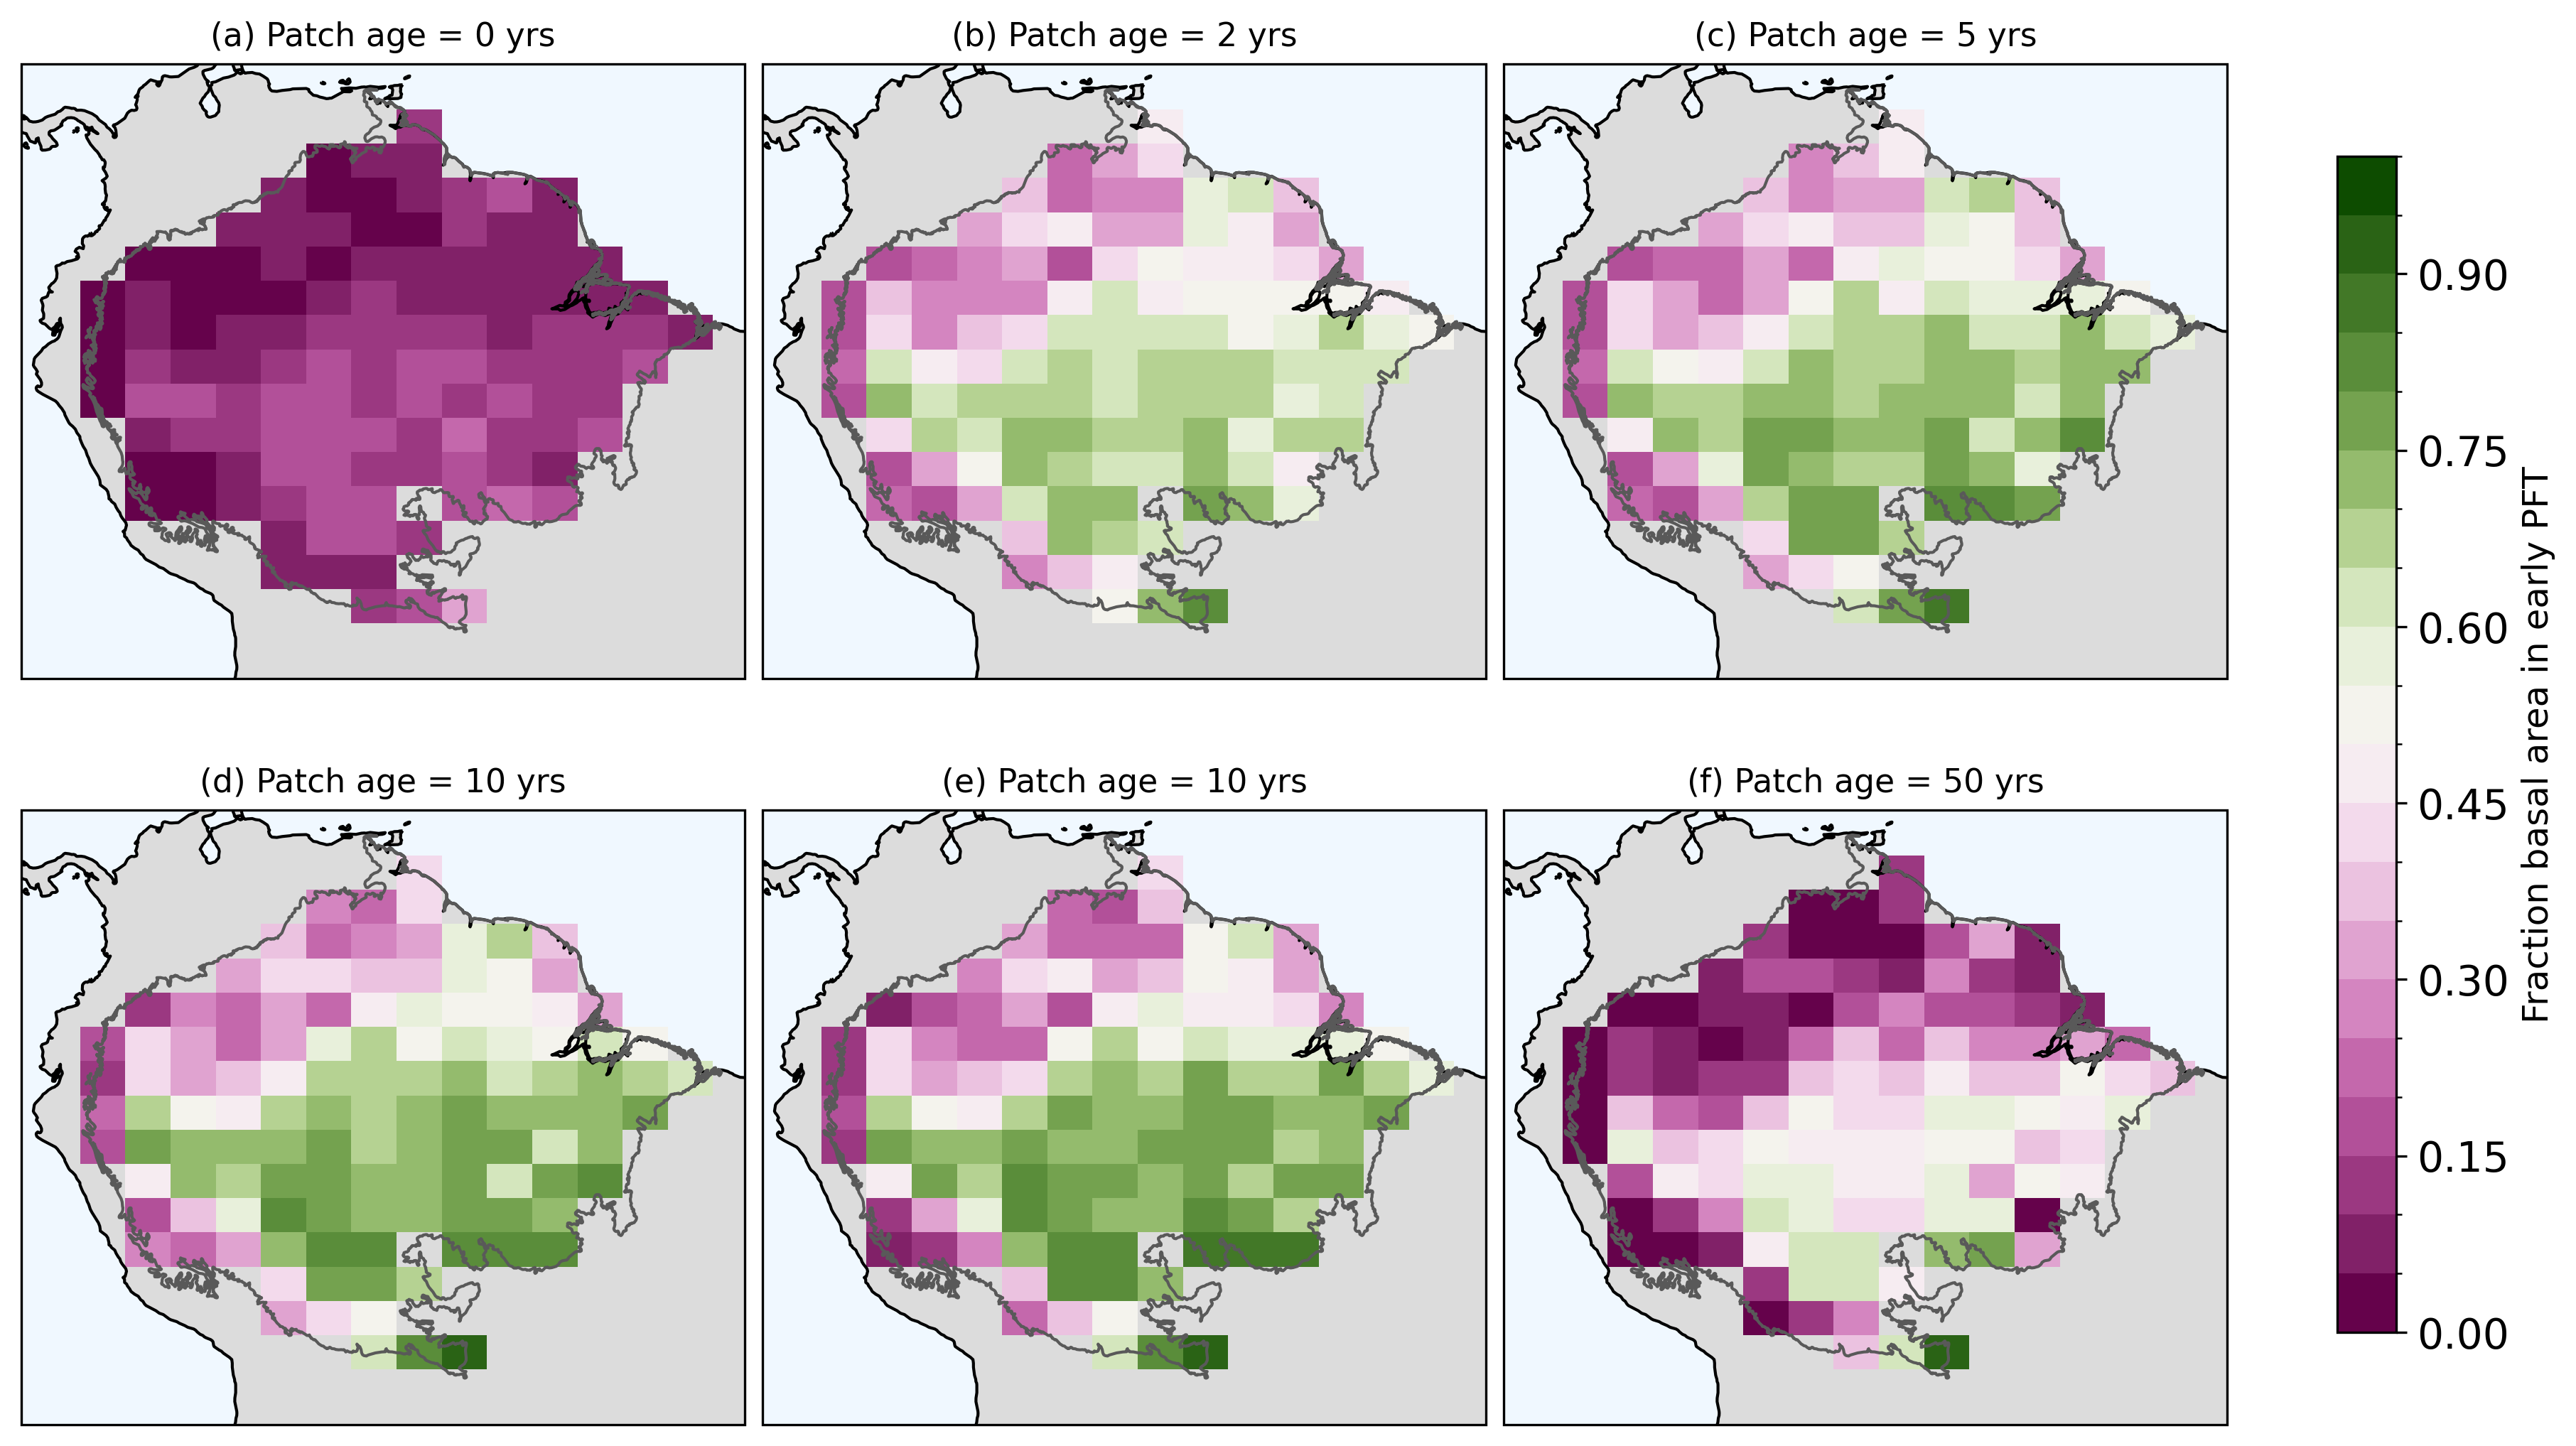

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
from cartopy.io.shapereader import Reader

# 1. Properly initialize the grid with Cartopy projections
fig, axes = plt.subplots(
    nrows=2, 
    ncols=3, 
    figsize=(12, 7), 
    constrained_layout=True,
    subplot_kw={'projection': ccrs.PlateCarree()} # <-- This automatically applies the projection to all 6 panels
)

# Flatten the axes array to make it easy to loop or index linearly (ax1=axes[0], ax2=axes[1], etc.)
ax_list = axes.ravel()

# Define common plotting limits and features to avoid repetitive code lines
extent = [min_lon_plotting-360., max_lon_plotting-360., min_lat_plotting, max_lat_plotting]
amazon_geom = list(Reader(Amazon_shapefile).geometries()) # <-- Cast to a list so it can be read multiple times

# Map your patch ages and index levels to a clean loop
patch_ages = [0, 2, 5, 10, 10, 50]  # Kept your original titles/ages
levels = [0, 2, 3, 4, 5, 6]        # fates_levage indices
panel_letters = ['a', 'b', 'c', 'd', 'e', 'f'] # Cleaned up duplicate panel letters

# 2. Loop through and plot each panel cleanly
for i, (ax, age, lvl, letter) in enumerate(zip(ax_list, patch_ages, levels, panel_letters)):
    
    # Plot the data onto the specific axis
    im = ba_ratio.isel(fates_levage=lvl).where(np.transpose(Mask) > 0).plot(
        x='lon', y='lat', 
        levels=np.linspace(0, 1, 21), 
        cmap=cm.bam, 
        transform=ccrs.PlateCarree(), 
        ax=ax, 
        add_colorbar=False # <-- Prevents xarray from generating individual colorbars
    )
    
    # Map decorations
    ax.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
    ax.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
    ax.coastlines()
    ax.add_geometries(amazon_geom, ccrs.PlateCarree(), 
                      edgecolor=(0.35, 0.35, 0.35, 1), facecolor=(0, 0, 0, 0))
    
    # Set spatial bounds
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(f'({letter}) Patch age = {age} yrs', fontsize=11)


# 3. Add the shared colorbar using the now-defined 'axes' variable
# We use 'im' because it captures the mappable from the last loop iteration (they all share the same scale)
cbar = fig.colorbar(im, ax=axes.ravel(), orientation='vertical', shrink=0.8, aspect=20)
cbar.set_label('Fraction basal area in early PFT', fontsize=12)

#fig.suptitle('Fraction basal area in early PFT by patch age', fontsize=14)

plt.show()

/global/homes/j/jkowalcz/.conda/envs/myenv/lib/python3.9/site-packages/xarray/plot/facetgrid.py:674: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()
/tmp/ipykernel_468443/150844497.py:6: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in fg.axes.flat:


Text(0.5, 0.98, 'Fraction early basal area by patch age')

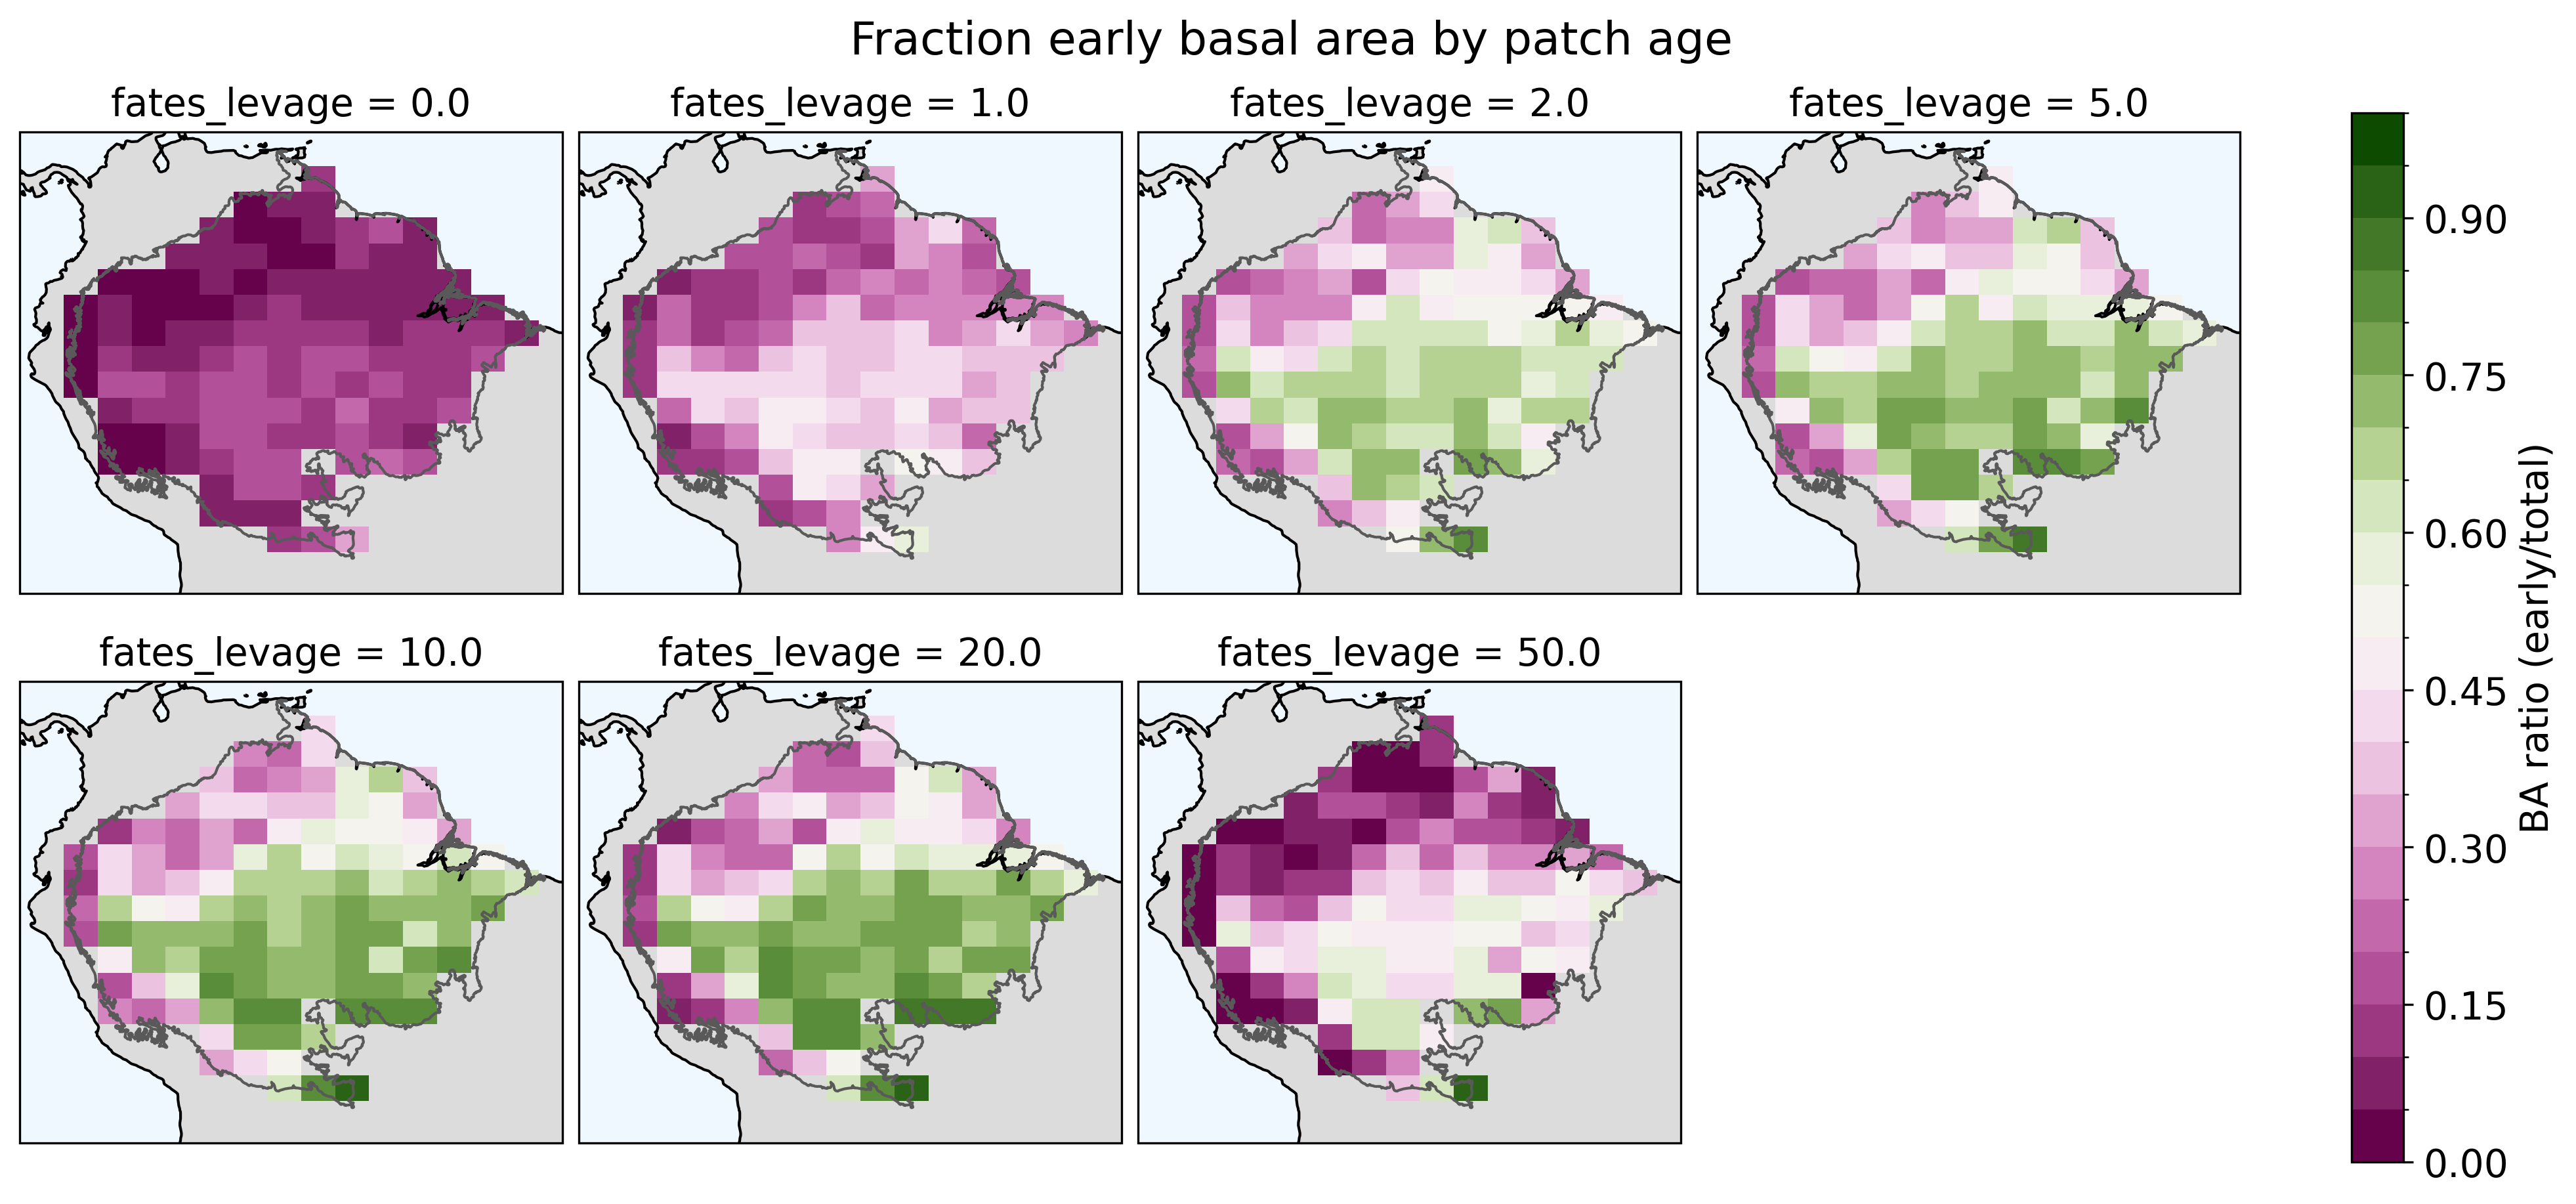

In [24]:
# Expand mask to include the fates_levage dimension
mask_expanded = np.expand_dims(Mask.T, axis=2)  # Shape: (23, 24, 1)
# This will broadcast to (23, 24, 7) automatically
fg = ba_ratio.where(mask_expanded > 0).plot(x='lon',y='lat',col='fates_levage',levels=np.linspace(0,1,21),cmap=cm.bam, col_wrap=4, transform=ccrs.PlateCarree(),cbar_kwargs=dict(location='right',orientation='vertical',label='BA ratio (early/total)'),subplot_kws=dict(projection=ccrs.PlateCarree()))

for ax in fg.axes.flat:
    ax.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
    ax.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
    ax.coastlines()
    ax.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                           edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
    ax.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])  #desired longitude range
    ax.set_ylim([min_lat_plotting,max_lat_plotting])  # desired latitude range

plt.suptitle('Fraction early basal area by patch age')
